In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Import dataset
df = pd.read_csv('medals.csv')

In [ ]:
# View of first 5 rows
df.head()

,medal_type,medal_code,medal_date,name,gender,discipline,event,event_type,url_event,code,country_code,country,country_long
0,Gold Medal,1.0,2024-07-27,Remco EVENEPOEL,M,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903136,BEL,Belgium,Belgium
1,Silver Medal,2.0,2024-07-27,Filippo GANNA,M,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1923520,ITA,Italy,Italy
2,Bronze Medal,3.0,2024-07-27,Wout van AERT,M,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1903147,BEL,Belgium,Belgium
3,Gold Medal,1.0,2024-07-27,Grace BROWN,W,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1940173,AUS,Australia,Australia
4,Silver Medal,2.0,2024-07-27,Anna HENDERSON,W,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1912525,GBR,Great Britain,Great Britain


In [35]:
# Check for missing values
df.isna().sum()

medal_type      0
medal_code      1
medal_date      0
name            0
gender          0
discipline      0
event           0
event_type      0
url_event       9
code            0
country_code    0
country         0
country_long    0
dtype: int64

In [36]:
# Check for number of unique values
df.nunique()

medal_type        3
medal_code        3
medal_date       16
name            810
gender            4
discipline       45
event           288
event_type        6
url_event       489
code            992
country_code     92
country          92
country_long     92
dtype: int64

In [37]:
# Remove unnecessary columns
df = df.drop(columns=['medal_code','event_type','url_event'])

In [ ]:
# Dataframe shape
print('DataFrame shape:' + '\n' + str(df.shape))

In [39]:
# Check for data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   medal_type    1044 non-null   object
 1   medal_date    1044 non-null   object
 2   name          1044 non-null   object
 3   gender        1044 non-null   object
 4   discipline    1044 non-null   object
 5   event         1044 non-null   object
 6   code          1044 non-null   object
 7   country_code  1044 non-null   object
 8   country       1044 non-null   object
 9   country_long  1044 non-null   object
dtypes: object(10)
memory usage: 81.7+ KB


First, I will find the **top 10 countries with the most medals in the 2024 Summer Olympics**. The final standing will be determined by the number of gold medals, silver medals and bronze medals won by each country, respectively

In [40]:
df1 = df.groupby('country_long')['medal_type'].value_counts()
df1 = df1.unstack().fillna(0).astype(int)
df1['Total Medals'] = df1.sum(axis=1)
df1

medal_type,Bronze Medal,Gold Medal,Silver Medal,Total Medals
country_long,,,,
AIN,1,1,3,5
Albania,2,0,0,2
Algeria,1,2,0,3
Argentina,1,1,1,3
Armenia,1,0,3,4
...,...,...,...,...
Uganda,0,1,1,2
Ukraine,4,3,5,12
United States of America,42,40,44,126


In [41]:
df1.sort_values(['Gold Medal','Silver Medal', 'Bronze Medal'], ascending=False).head(10)

medal_type,Bronze Medal,Gold Medal,Silver Medal,Total Medals
country_long,,,,
United States of America,42,40,44,126
People's Republic of China,24,40,27,91
Japan,13,20,12,45
Australia,16,18,19,53
France,22,16,26,64
Netherlands,12,15,7,34
Great Britain,29,14,22,65
Republic of Korea,10,13,9,32
Italy,15,12,13,40


**Top 10 countries with the most medals** are: USA, China, Japan, Australia, Great Britain, Germany, France, Italy, Netherlands, South Korea, Italy, Germany.
- USA and China have the highest number of gold medals, doubling the number of gold medals of the third-placed country, Japan. Having higher number of Silver and Bronze medals, USA is the leading country, emphasizing its dominance not only in economy, but also in sports. 

Next, I will identify the sports with the highest number of medals won. In order to do this, I will group the data by sport and medal

In [83]:
# Count the number of events in for each discipline
df.groupby('discipline')['event'].nunique().sort_values(ascending=False).head(5)

discipline
Athletics    48
Swimming     35
Wrestling    18
Shooting     15
Judo         15
Name: event, dtype: int64

In [42]:
df2 = df[['medal_type','discipline']]
df2 = df2.groupby('discipline')['medal_type'].value_counts().unstack().fillna(0).astype(int)
df2['Total Medals'] = df2.sum(axis=1)
df2 = df2.reset_index()

In [ ]:
# Find top 5 disciplines with the highest number of gold medals
df2.sort_values(['Gold Medal'], ascending=False).head(5)

medal_type,discipline,Bronze Medal,Gold Medal,Silver Medal,Total Medals
4,Athletics,49,48,48,145
35,Swimming,34,35,36,105
44,Wrestling,36,18,18,72
31,Shooting,15,15,15,45
24,Judo,30,15,15,60


In [ ]:
# Find top 5 disciplines with most medals
df2.sort_values(['Total Medals'], ascending=False).head(5)

medal_type,discipline,Bronze Medal,Gold Medal,Silver Medal,Total Medals
4,Athletics,49,48,48,145
35,Swimming,34,35,36,105
44,Wrestling,36,18,18,72
24,Judo,30,15,15,60
8,Boxing,26,13,13,52


The analysis shows that **Athletics has the highest number of gold medals, following by Swimming and Wrestling**. This order remains consistent for the number of total medals. These observations are explained by the fact that these sports have highest number of events. 

For each country, I further analyze which discipline contributed the highest number of medals

In [ ]:
# Group country and medal type by discipline
df3 = df[['country_long','medal_type','discipline']]
df3 = df3.groupby('discipline')[['country_long','medal_type']].value_counts().unstack().fillna(0).astype(int)
df3['Total Medals'] = df3.sum(axis=1)
df3 = df3.reset_index()

In [87]:
df3_sorted = df3.sort_values(['Gold Medal'], ascending=False)
df3_sorted.drop_duplicates(subset='country_long',keep='first').head(10)

medal_type,discipline,country_long,Bronze Medal,Gold Medal,Silver Medal,Total Medals
76,Athletics,United States of America,9,14,11,34
479,Wrestling,Japan,2,8,1,11
199,Diving,People's Republic of China,1,8,2,11
364,Swimming,Australia,3,7,8,18
127,Boxing,Uzbekistan,0,5,0,5
10,Archery,Republic of Korea,1,5,1,7
366,Swimming,France,2,4,1,7
297,Rowing,Netherlands,1,4,3,8
58,Athletics,Kenya,5,4,2,11
204,Equestrian,Germany,0,4,1,5


- The table shows **the specific golden sports of top 10 countries**. Athletics is a stronghold for USA (14 gold medals) and Kenya, while for Australia (7 gold medals) and France, swimming has always been a medal-rich sport. 
- For Asian countries like Japan and South Korea, their biggest strengths were embraced in their national sports. China also got 8 gold medals from diving. 

Next, I will look at another dataset containing lists of athletes and their information, including nationalities and medals won

In [ ]:
# Import dataset
df4 = pd.read_csv('medallists.csv')
df4.head()

,medal_date,medal_type,medal_code,name,gender,country_code,country,country_long,nationality_code,nationality,...,team,team_gender,discipline,event,event_type,url_event,birth_date,code_athlete,code_team,is_medallist
0,2024-07-27,Gold Medal,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,2000-01-25,1903136,NaN,True
1,2024-07-27,Silver Medal,2.0,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1996-07-25,1923520,NaN,True
2,2024-07-27,Bronze Medal,3.0,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1994-09-15,1903147,NaN,True
3,2024-07-27,Gold Medal,1.0,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1992-07-07,1940173,NaN,True
4,2024-07-27,Silver Medal,2.0,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1998-11-14,1912525,NaN,True


In [ ]:
# Check for missing values
df4.isna().sum()

medal_date            0
medal_type            0
medal_code            1
name                  0
gender                0
country_code          0
country               0
country_long          0
nationality_code      1
nationality           1
nationality_long      1
team                760
team_gender         760
discipline            0
event                 0
event_type            0
url_event            21
birth_date            0
code_athlete          0
code_team           760
is_medallist          0
dtype: int64

In [ ]:
# Check for data types
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2315 entries, 0 to 2314
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   medal_date        2315 non-null   object 
 1   medal_type        2315 non-null   object 
 2   medal_code        2314 non-null   float64
 3   name              2315 non-null   object 
 4   gender            2315 non-null   object 
 5   country_code      2315 non-null   object 
 6   country           2315 non-null   object 
 7   country_long      2315 non-null   object 
 8   nationality_code  2314 non-null   object 
 9   nationality       2314 non-null   object 
 10  nationality_long  2314 non-null   object 
 11  team              1555 non-null   object 
 12  team_gender       1555 non-null   object 
 13  discipline        2315 non-null   object 
 14  event             2315 non-null   object 
 15  event_type        2315 non-null   object 
 16  url_event         2294 non-null   object 


In [51]:
df4['is_medallist'].value_counts()

is_medallist
True     2268
False      47
Name: count, dtype: int64

In [ ]:
# Drop unused columns
df4 = df4.drop(columns=['team_gender','team','code_team','url_event','medal_code'])

In [54]:
df4.isna().sum()

medal_date          0
medal_type          0
name                0
gender              0
country_code        0
country             0
country_long        0
nationality_code    1
nationality         1
nationality_long    1
discipline          0
event               0
event_type          0
birth_date          0
code_athlete        0
is_medallist        0
dtype: int64

In [ ]:
# Drop rows with missing values
df4 = df4.dropna()

In [ ]:
df4['is_medallist'].value_counts()

is_medallist
True     2267
False      47
Name: count, dtype: int64

In [ ]:
# Only choose athletes with medals to analyze
df5 = df4[df4['is_medallist'] == True]
df5.shape

(2267, 16)

In [60]:
df5.head()

,medal_date,medal_type,name,gender,country_code,country,country_long,nationality_code,nationality,nationality_long,discipline,event,event_type,birth_date,code_athlete,is_medallist
0,2024-07-27,Gold Medal,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,Belgium,Cycling Road,Men's Individual Time Trial,ATH,2000-01-25,1903136,True
1,2024-07-27,Silver Medal,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,Italy,Cycling Road,Men's Individual Time Trial,ATH,1996-07-25,1923520,True
2,2024-07-27,Bronze Medal,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,Belgium,Cycling Road,Men's Individual Time Trial,ATH,1994-09-15,1903147,True
3,2024-07-27,Gold Medal,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,Australia,Cycling Road,Women's Individual Time Trial,ATH,1992-07-07,1940173,True
4,2024-07-27,Silver Medal,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,Great Britain,Cycling Road,Women's Individual Time Trial,ATH,1998-11-14,1912525,True


In [ ]:
# Convert date columns to datetime type
df5['medal_date'] = pd.to_datetime(df5['medal_date'])
df5['birth_date'] = pd.to_datetime(df5['birth_date'])

C:\Users\Thu\AppData\Local\Temp\ipykernel_16260\2425368211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['medal_date'] = pd.to_datetime(df5['medal_date'])
C:\Users\Thu\AppData\Local\Temp\ipykernel_16260\2425368211.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['birth_date'] = pd.to_datetime(df5['birth_date'])


In [ ]:
# Calculate the age of atheletes at the time of receiving the medals 
df5['age_at_medal_date'] = (df5['medal_date'] - df5['birth_date']).dt.days // 365

C:\Users\Thu\AppData\Local\Temp\ipykernel_16260\1863523225.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df5['age_at_medal_date'] = (df5['medal_date'] - df5['birth_date']).dt.days // 365


I will find the youngest/oldest female/male athletes who won Gold medals in the 2024 Summer Olympics

In [63]:
df5_filtered = df5[['gender','name','nationality_long','age_at_medal_date','medal_type','event','discipline']]

In [90]:
df5_filtered[(df5_filtered['gender'] == 'Male') & (df5_filtered['medal_type'] == 'Gold Medal')].sort_values('age_at_medal_date',ascending=True)

,gender,name,nationality_long,age_at_medal_date,medal_type,event,discipline
1891,Male,WILSON Quincy,United States of America,16,Gold Medal,Men's 4 x 400m Relay,Athletics
1747,Male,CUBARSI Pau,Spain,17,Gold Medal,Men,Football
87,Male,SHENG Lihao,People's Republic of China,19,Gold Medal,10m Air Rifle Men,Shooting
807,Male,SHENG Lihao,People's Republic of China,19,Gold Medal,10m Air Rifle Mixed Team,Shooting
613,Male,ROBERTS Toby,Great Britain,19,Gold Medal,Men's Boulder & Lead,Sport Climbing
...,...,...,...,...,...,...,...
963,Male,MIKEC Damir,Serbia,40,Gold Medal,10m Air Pistol Mixed Team,Shooting
435,Male,LOPEZ NUNEZ Mijain,Cuba,41,Gold Medal,Men's Greco-Roman 130kg,Wrestling
1122,Male,MAHER Ben,Great Britain,41,Gold Medal,Jumping Team,Equestrian
70,Male,JUNG Michael,Germany,42,Gold Medal,Eventing Individual,Equestrian


In [91]:
df5_filtered[(df5_filtered['gender'] == 'Female') & (df5_filtered['medal_type'] == 'Gold Medal')].sort_values('age_at_medal_date',ascending=True)

,gender,name,nationality_long,age_at_medal_date,medal_type,event,discipline
432,Female,TREW Arisa,Australia,14,Gold Medal,Women's Park,Skateboarding
52,Female,YOSHIZAWA Coco,Japan,14,Gold Medal,Women's Street,Skateboarding
901,Female,RIVERA Hezly,United States of America,16,Gold Medal,Women's Team,Artistic Gymnastics
90,Female,BAN Hyojin,Republic of Korea,16,Gold Medal,10m Air Rifle Women,Shooting
1406,Female,SHACKELL Alex,United States of America,17,Gold Medal,Women's 4 x 100m Medley Relay,Swimming
...,...,...,...,...,...,...,...
915,Female,NAVARRIA Mara,Italy,39,Gold Medal,Women's Épée Team,Fencing
1469,Female,BACOSI Diana,Italy,41,Gold Medal,Skeet Mixed Team,Shooting
2160,Female,TAURASI Diana,United States of America,42,Gold Medal,Women,Basketball
2027,Female,LUNDE Katrine,Norway,44,Gold Medal,Women,Handball


- The analysis shows that the American track and field athlete, Quincy Wilson, was the youngest male athlete to win a gold medal at the age of 16 years. According to Wikipedia, he was the youngest track and field Olympic gold medalist in history. Also, at the age of 19, the Chinese sport shooter Lihao Sheng, got 2 gold medals. 
- At the age of 14, Arisa Trew from Autralia and Coco Yoshizawa both won gold medals in skateboarding. 

- On the other hand, at the age of 43, Hans Lindberg won a gold medal in handball for Denmark, which is considered "the best way to end his international career".
- At the age of 55, the German "Queen of Dressage" won her 8th gold medal among 14 won Olympics medals. This medal also made her the first athlete to win a medal at seven different Olympic Games editions (Summer or Winter) (https://www.olympics.com/en/news/isabell-werth-all-medals-records-titles-full-list)

In [101]:
female_athletes = df5[df5['gender'] == 'Female']
female_athletes

,medal_date,medal_type,name,gender,country_code,country,country_long,nationality_code,nationality,nationality_long,discipline,event,event_type,birth_date,code_athlete,is_medallist,age_at_medal_date
3,2024-07-27,Gold Medal,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,Australia,Cycling Road,Women's Individual Time Trial,ATH,1992-07-07,1940173,True,32
4,2024-07-27,Silver Medal,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,Great Britain,Cycling Road,Women's Individual Time Trial,ATH,1998-11-14,1912525,True,25
5,2024-07-27,Bronze Medal,DYGERT Chloe,Female,USA,United States,United States of America,USA,United States,United States of America,Cycling Road,Women's Individual Time Trial,ATH,1997-01-01,1955079,True,27
9,2024-07-27,Gold Medal,KONG Man Wai Vivian,Female,HKG,"Hong Kong, China","Hong Kong, China",HKG,"Hong Kong, China","Hong Kong, China",Fencing,Women's Épée Individual,HATH,1994-02-08,1963262,True,30
10,2024-07-27,Silver Medal,MALLO-BRETON Auriane,Female,FRA,France,France,FRA,France,France,Fencing,Women's Épée Individual,HATH,1993-10-11,1916183,True,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2310,2024-08-10,Bronze Medal,CENTOFANTI Martina,Female,ITA,Italy,Italy,ITA,Italy,Italy,Rhythmic Gymnastics,Group All-Around,TEAM,1998-05-19,1923700,True,26
2311,2024-08-10,Bronze Medal,DURANTI Agnese,Female,ITA,Italy,Italy,ITA,Italy,Italy,Rhythmic Gymnastics,Group All-Around,TEAM,2000-12-18,1923701,True,23
2312,2024-08-10,Bronze Medal,MAURELLI Alessia,Female,ITA,Italy,Italy,ITA,Italy,Italy,Rhythmic Gymnastics,Group All-Around,TEAM,1996-08-22,1923699,True,27
2313,2024-08-10,Bronze Medal,MOGUREAN Daniela,Female,ITA,Italy,Italy,ITA,Italy,Italy,Rhythmic Gymnastics,Group All-Around,TEAM,2001-07-16,1923703,True,23


In [102]:
female_filtered = female_athletes.groupby('name')[['nationality_long','discipline','medal_type']].value_counts().unstack().fillna(0).astype(int)
female_filtered['Total Medals'] = female_filtered.sum(axis=1)
female_filtered.sort_values('Gold Medal',ascending=False).head(5)

,,medal_type,Bronze Medal,Gold Medal,Silver Medal,Total Medals
name,nationality_long,discipline,,,,
THOMAS Gabrielle,United States of America,Athletics,0,3,0,3
LIM Sihyeon,Republic of Korea,Archery,0,3,0,3
BILES Simone,United States of America,Artistic Gymnastics,0,3,1,4
O'CALLAGHAN Mollie,Australia,Swimming,1,3,1,5
McINTOSH Summer,Canada,Swimming,0,3,1,4


In [103]:
female_filtered.sort_values('Total Medals',ascending=False).head(5)

,,medal_type,Bronze Medal,Gold Medal,Silver Medal,Total Medals
name,nationality_long,discipline,,,,
ZHANG Yufei,People's Republic of China,Swimming,5,0,1,6
McKEOWN Kaylee,Australia,Swimming,2,2,1,5
O'CALLAGHAN Mollie,Australia,Swimming,1,3,1,5
SMITH Regan,United States of America,Swimming,0,2,3,5
HUSKE Torri,United States of America,Swimming,0,3,2,5


In [104]:
male_athletes = df5[df5['gender'] == 'Male']
male_athletes

,medal_date,medal_type,name,gender,country_code,country,country_long,nationality_code,nationality,nationality_long,discipline,event,event_type,birth_date,code_athlete,is_medallist,age_at_medal_date
0,2024-07-27,Gold Medal,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,Belgium,Cycling Road,Men's Individual Time Trial,ATH,2000-01-25,1903136,True,24
1,2024-07-27,Silver Medal,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,Italy,Cycling Road,Men's Individual Time Trial,ATH,1996-07-25,1923520,True,28
2,2024-07-27,Bronze Medal,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,Belgium,Cycling Road,Men's Individual Time Trial,ATH,1994-09-15,1903147,True,29
6,2024-07-27,Gold Medal,OH Sanguk,Male,KOR,Korea,Republic of Korea,KOR,Korea,Republic of Korea,Fencing,Men's Sabre Individual,HATH,1996-09-30,1927149,True,27
7,2024-07-27,Silver Medal,FERJANI Fares,Male,TUN,Tunisia,Tunisia,TUN,Tunisia,Tunisia,Fencing,Men's Sabre Individual,HATH,1997-07-22,1937783,True,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,2024-08-11,Bronze Medal,BOWEN Alex,Male,USA,United States,United States of America,USA,United States,United States of America,Water Polo,Men,HTEAM,1993-09-04,1908350,True,30
2296,2024-08-11,Bronze Medal,DODD Chase William,Male,USA,United States,United States of America,USA,United States,United States of America,Water Polo,Men,HTEAM,2003-04-05,1908354,True,21
2297,2024-08-11,Bronze Medal,DODD Ryder,Male,USA,United States,United States of America,USA,United States,United States of America,Water Polo,Men,HTEAM,2006-01-19,1908355,True,18
2298,2024-08-11,Bronze Medal,IRVING Max,Male,USA,United States,United States of America,USA,United States,United States of America,Water Polo,Men,HTEAM,1995-05-21,1908361,True,29


In [105]:
male_filtered = male_athletes.groupby('name')[['nationality_long','discipline','medal_type']].value_counts().unstack().fillna(0).astype(int)
male_filtered['Total Medals'] = male_filtered.sum(axis=1)
male_filtered.sort_values('Gold Medal',ascending=False).head(5)

,,medal_type,Bronze Medal,Gold Medal,Silver Medal,Total Medals
name,nationality_long,discipline,,,,
MARCHAND Leon,France,Swimming,1,4,0,5
LAVREYSEN Harrie,Netherlands,Cycling Track,0,3,0,3
OKA Shinnosuke,Japan,Artistic Gymnastics,1,3,0,4
KIM Woojin,Republic of Korea,Archery,0,3,0,3
DRESSEL Caeleb,United States of America,Swimming,0,2,1,3


In [106]:
male_filtered.sort_values('Total Medals',ascending=False).head(5)

,,medal_type,Bronze Medal,Gold Medal,Silver Medal,Total Medals
name,nationality_long,discipline,,,,
MARCHAND Leon,France,Swimming,1,4,0,5
OKA Shinnosuke,Japan,Artistic Gymnastics,1,3,0,4
XU Jiayu,People's Republic of China,Swimming,0,1,2,3
CHALMERS Kyle,Australia,Swimming,1,0,2,3
DRESSEL Caeleb,United States of America,Swimming,0,2,1,3


The exploration of the highest and lowest ages of gold medalists from different disciplines shows that ages differ by sport. According to a research by The ARC Centre of Excellence in Population Ageing Research, this difference is explained by the match of skills at different ages to the sport's specific requirements (https://cepar.edu.au/sites/default/files/peak-performance-age-sport.pdf). To explain this further, I will carry out some data exploratory steps in understanding the age difference of medalists by gender and discipline.

In [ ]:
# Age distribution of female medalists
female_athletes['age_at_medal_date'].describe()

count    1141.000000
mean       26.115688
std         4.904771
min        14.000000
25%        23.000000
50%        26.000000
75%        29.000000
max        58.000000
Name: age_at_medal_date, dtype: float64

In [126]:
# Calculate the average age of medalists in each sport
female_athletes.groupby('discipline')['age_at_medal_date'].mean().sort_values(ascending=False).head(5)

discipline
Equestrian               39.384615
Cycling Road             30.000000
Sailing                  29.857143
Handball                 29.489362
Cycling Mountain Bike    29.000000
Name: age_at_medal_date, dtype: float64

In [127]:
female_athletes.groupby('discipline')['age_at_medal_date'].mean().sort_values(ascending=True).head(5)

discipline
Skateboarding          15.000000
Breaking               20.000000
Rhythmic Gymnastics    21.388889
Artistic Gymnastics    22.166667
Diving                 22.333333
Name: age_at_medal_date, dtype: float64

In [ ]:
# Age distribution of male medalists
male_athletes['age_at_medal_date'].describe()

count    1126.000000
mean       26.949378
std         4.988530
min        16.000000
25%        23.000000
50%        27.000000
75%        30.000000
max        57.000000
Name: age_at_medal_date, dtype: float64

In [128]:
# Calculate the average age of medalists in each sport
male_athletes.groupby('discipline')['age_at_medal_date'].mean().sort_values(ascending=False).head(5)

discipline
Equestrian            39.958333
Breaking              31.000000
Golf                  31.000000
Cycling BMX Racing    31.000000
Volleyball            30.972973
Name: age_at_medal_date, dtype: float64

In [129]:
# Calculate the average age of medalists in each sport
male_athletes.groupby('discipline')['age_at_medal_date'].mean().sort_values(ascending=True).head(5)

discipline
Trampoline Gymnastics    21.666667
Football                 22.306452
Sport Climbing           22.500000
Marathon Swimming        23.000000
Taekwondo                23.687500
Name: age_at_medal_date, dtype: float64

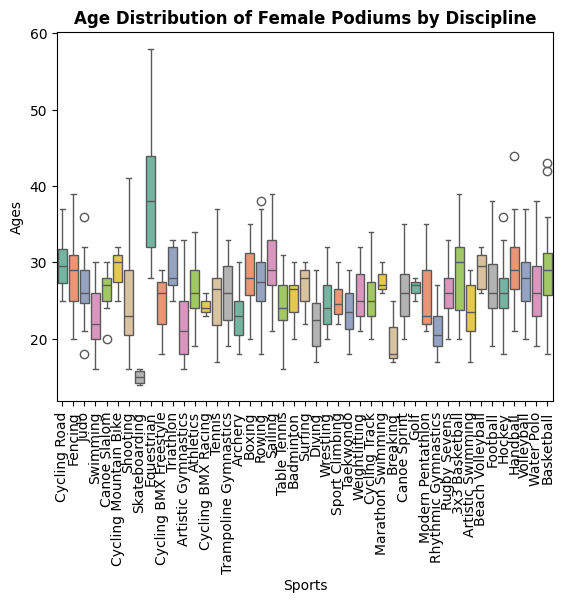

In [ ]:
# Visualize the age distribution of female podiums by discipline
sns.boxplot(x='discipline', y='age_at_medal_date', data=female_athletes, hue = 'discipline', palette='Set2')
plt.xticks(rotation=90) 
plt.title('Age Distribution of Female Podiums by Discipline',fontweight='bold')
plt.xlabel('Sports')
plt.ylabel('Ages')
plt.show()

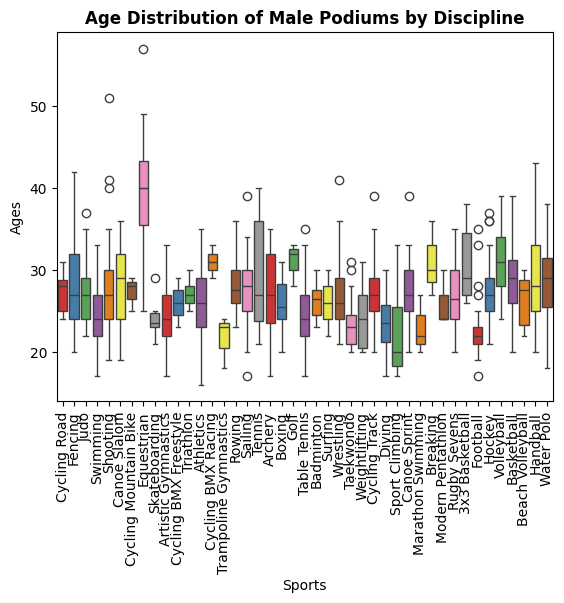

In [ ]:
# Visualize the age distribution of male podiums by discipline
sns.boxplot(x='discipline', y='age_at_medal_date', data=male_athletes, hue = 'discipline', palette='Set1')
plt.xticks(rotation=90) 
plt.title('Age Distribution of Male Podiums by Discipline',fontweight='bold')
plt.xlabel('Sports')
plt.ylabel('Ages')
plt.show()

- The average age of males is higher than females (26.95 vs 26.11)
- For females, sports with the highest average ages include Equestrian, Sailing and Cycling, while male Equestrian, Cycling, Golf and Breaking athletes are the oldest
- The youngest female athletes are most commonly found in Skateboarding, Gymnastics, and Breaking events, while the youngest male athletes primarily compete in Gymnastics, Football, Sport Climbing
- Though differing in sport disciplines, one common thing between male and female podiums is that athletes in sports that demands speed and power (Gymnastics, Sport Climbing) often reach the peak of their careers in their mid-20s, while athletes in tactical, precision sports with low physical loads such as Equestrian, Golf, Sailing even peaks around their 40s-50s. 
- Football is an exception in the list, since the Olympic Men's Football event faces age limit imposed by the International Olympics Committee (https://www.sportingnews.com/au/olympics/news/football-olympics-eligibility-rules-men-age-23-women/9961edc5d6ab65accc6798b2)
- Skateboarding, having been introduced since the 2020 Olympics Tokyo, is one of the few disciplines that has seen some of the youngest podiums ever. The youngest athelete competing in the 2024 Olympics Paris is a 11-year-old female skateboarder from China. According to an article by the Sporting News, the reason why there are a lot of teenage skateboarders is because "Having a smaller body offers an edge in skateboarding, especially for any tricks that require rotation because the body's center of gravity is closer to the board, among other things"(https://www.sportingnews.com/us/olympics/news/olympics-skateboarders-young-age-rules-teenagers-2024-medal/adb88268c59bd1823b47bb69). This gives the young athletes big advantages over their competitors, which was cleary indicated by the age of the 2024 gold medalists (shown above), the 2020 gold medalists (Momiji Nishiya - winning at the age of 13. She is the youngest person ever to win a gold medal for Japan, and the third youngest to ever win an event at the Summer Olympics)
- There is also a notable gap in Breaking discipline, in which the average ages of females and males are 20 and 31, respectively. Although there is no properly scientific research on this, based on my own research, this difference may possibly be from gap in muscularity level of female and male body. In the Olympic Games, B-Boys and B-Girls will have their performance assessed based on six criteria: creativity, personality, technique, variety, performativity, and musicality (Olympics.com). While the other 5 aspects are individual to each athlete, reflecting their unique skills, style, and talent, 'technique' is dependent on muscularity. For example, spinning and acrobatic movements may need strong muscles to support and control the body. According to The ARC Centre of Excellence in Population Ageing Research, women generally have less muscle mass than men, and they tend to lose it earlier. 